(mmm_var_budget_optimization)=
# Combining an MMM and a Bayesian VAR in One Budget Decision

A media mix model (MMM) estimates how channel spend changes a near-term business outcome, here subscription trial starts. A vector autoregression with exogenous inputs (VARX) answers a different question: how does the same spend move persistent engagement indicators, such as app-store visits and community sign-ups, over time?

This notebook combines those two views in one budget decision. We fit the models separately, propagate both posterior distributions into a custom PyMC-Marketing utility, and compare the resulting allocations. The data, labels, and coefficients are entirely simulated.

```{note}
Here, **joint optimization** means that one decision uses both fitted posterior distributions. It does not mean joint estimation: the MMM and VARX retain separate likelihoods and separate fits.
```


## Prepare Notebook

We load the modeling, plotting, and optimization tools used throughout the notebook.

In [16]:
import warnings

warnings.filterwarnings("ignore")

In [17]:
import arviz as az
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import pytensor.tensor as pt
import xarray as xr
from impulso import VAR, VARData, compute_ma_phi, lag_matrices
from impulso.samplers import NUTSSampler
from pytensor.xtensor.type import XTensorVariable, as_xtensor

from pymc_marketing.mmm import LogisticSaturation, NoAdstock
from pymc_marketing.mmm.budget_optimizer import BudgetOptimizer
from pymc_marketing.mmm.mmm import MMM, BudgetOptimizerWrapper
from pymc_marketing.mmm.utility import UtilityFunctionType

az.style.use("arviz-darkgrid")
plt.rcParams["figure.figsize"] = [12, 7]
plt.rcParams["figure.dpi"] = 100

%load_ext autoreload
%autoreload 2
%config InlineBackend.figure_format = "retina"

seed: int = sum(map(ord, "mmm_var_budget_optimization"))
rng: np.random.Generator = np.random.default_rng(seed=seed)

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


## Simulate the Marketing System

Suppose a fictional subscription app allocates two weekly channel budgets:

- **Affiliate marketing** generates more trial starts inside the planning window.
- **Creator partnerships** generate fewer immediate trials but have a larger, persistent effect on app discovery and community growth.

The two models observe the same spend while measuring different stages of the acquisition journey.

| Model | Outcomes | Role in the decision |
| --- | --- | --- |
| MMM | Trial starts | Direct, saturating response |
| VARX | App-store visits and community sign-ups | Persistent engagement response |

To keep the mechanism visible, the simulated MMM uses saturation without adstock. This separates its direct trial-start response from the VARX's persistent engagement response. A production analysis should use its validated MMM specification and check that the two objectives do not count the same effect twice.

In [18]:
channels = ["affiliate_marketing", "creator_partnerships"]
n_weeks = 104
dates = pd.date_range("2022-04-04", periods=n_weeks, freq="W-MON")

affiliate_marketing = rng.uniform(0.05, 1.0, n_weeks)
creator_partnerships = rng.uniform(0.05, 1.0, n_weeks)
spend = np.column_stack([affiliate_marketing, creator_partnerships])

trial_starts = (
    3.5
    + 2.7 * (1 - np.exp(-2.8 * affiliate_marketing))
    + 1.4 * (1 - np.exp(-1.8 * creator_partnerships))
    + rng.normal(0, 0.18, n_weeks)
)

# A stable two-variable VARX. Creator partnerships have the larger engagement loadings.
A_true = np.array([[0.50, 0.12], [0.10, 0.42]])
B_exog_true = np.array([[0.20, 0.75], [0.25, 0.55]])
engagement_state = np.zeros((n_weeks, 2))
for week in range(1, n_weeks):
    engagement_state[week] = (
        A_true @ engagement_state[week - 1]
        + B_exog_true @ spend[week]
        + rng.normal(0, 0.12, 2)
    )

data = pd.DataFrame(
    {
        "date": dates,
        "affiliate_marketing": affiliate_marketing,
        "creator_partnerships": creator_partnerships,
        "trial_starts": trial_starts,
        "app_store_visits": engagement_state[:, 0],
        "community_signups": engagement_state[:, 1],
    }
)
data.head()

,date,affiliate_marketing,creator_partnerships,trial_starts,app_store_visits,community_signups
0,2022-04-04,0.992573,0.335087,6.827177,0.000000,0.000000
1,2022-04-11,0.119053,0.321529,4.890285,0.438435,0.249622
2,2022-04-18,0.692021,0.608007,6.765758,0.983796,0.412786
3,2022-04-25,0.754566,0.999229,6.925945,1.364667,1.057960
4,2022-05-02,0.832168,0.804431,7.050264,1.516237,1.032826


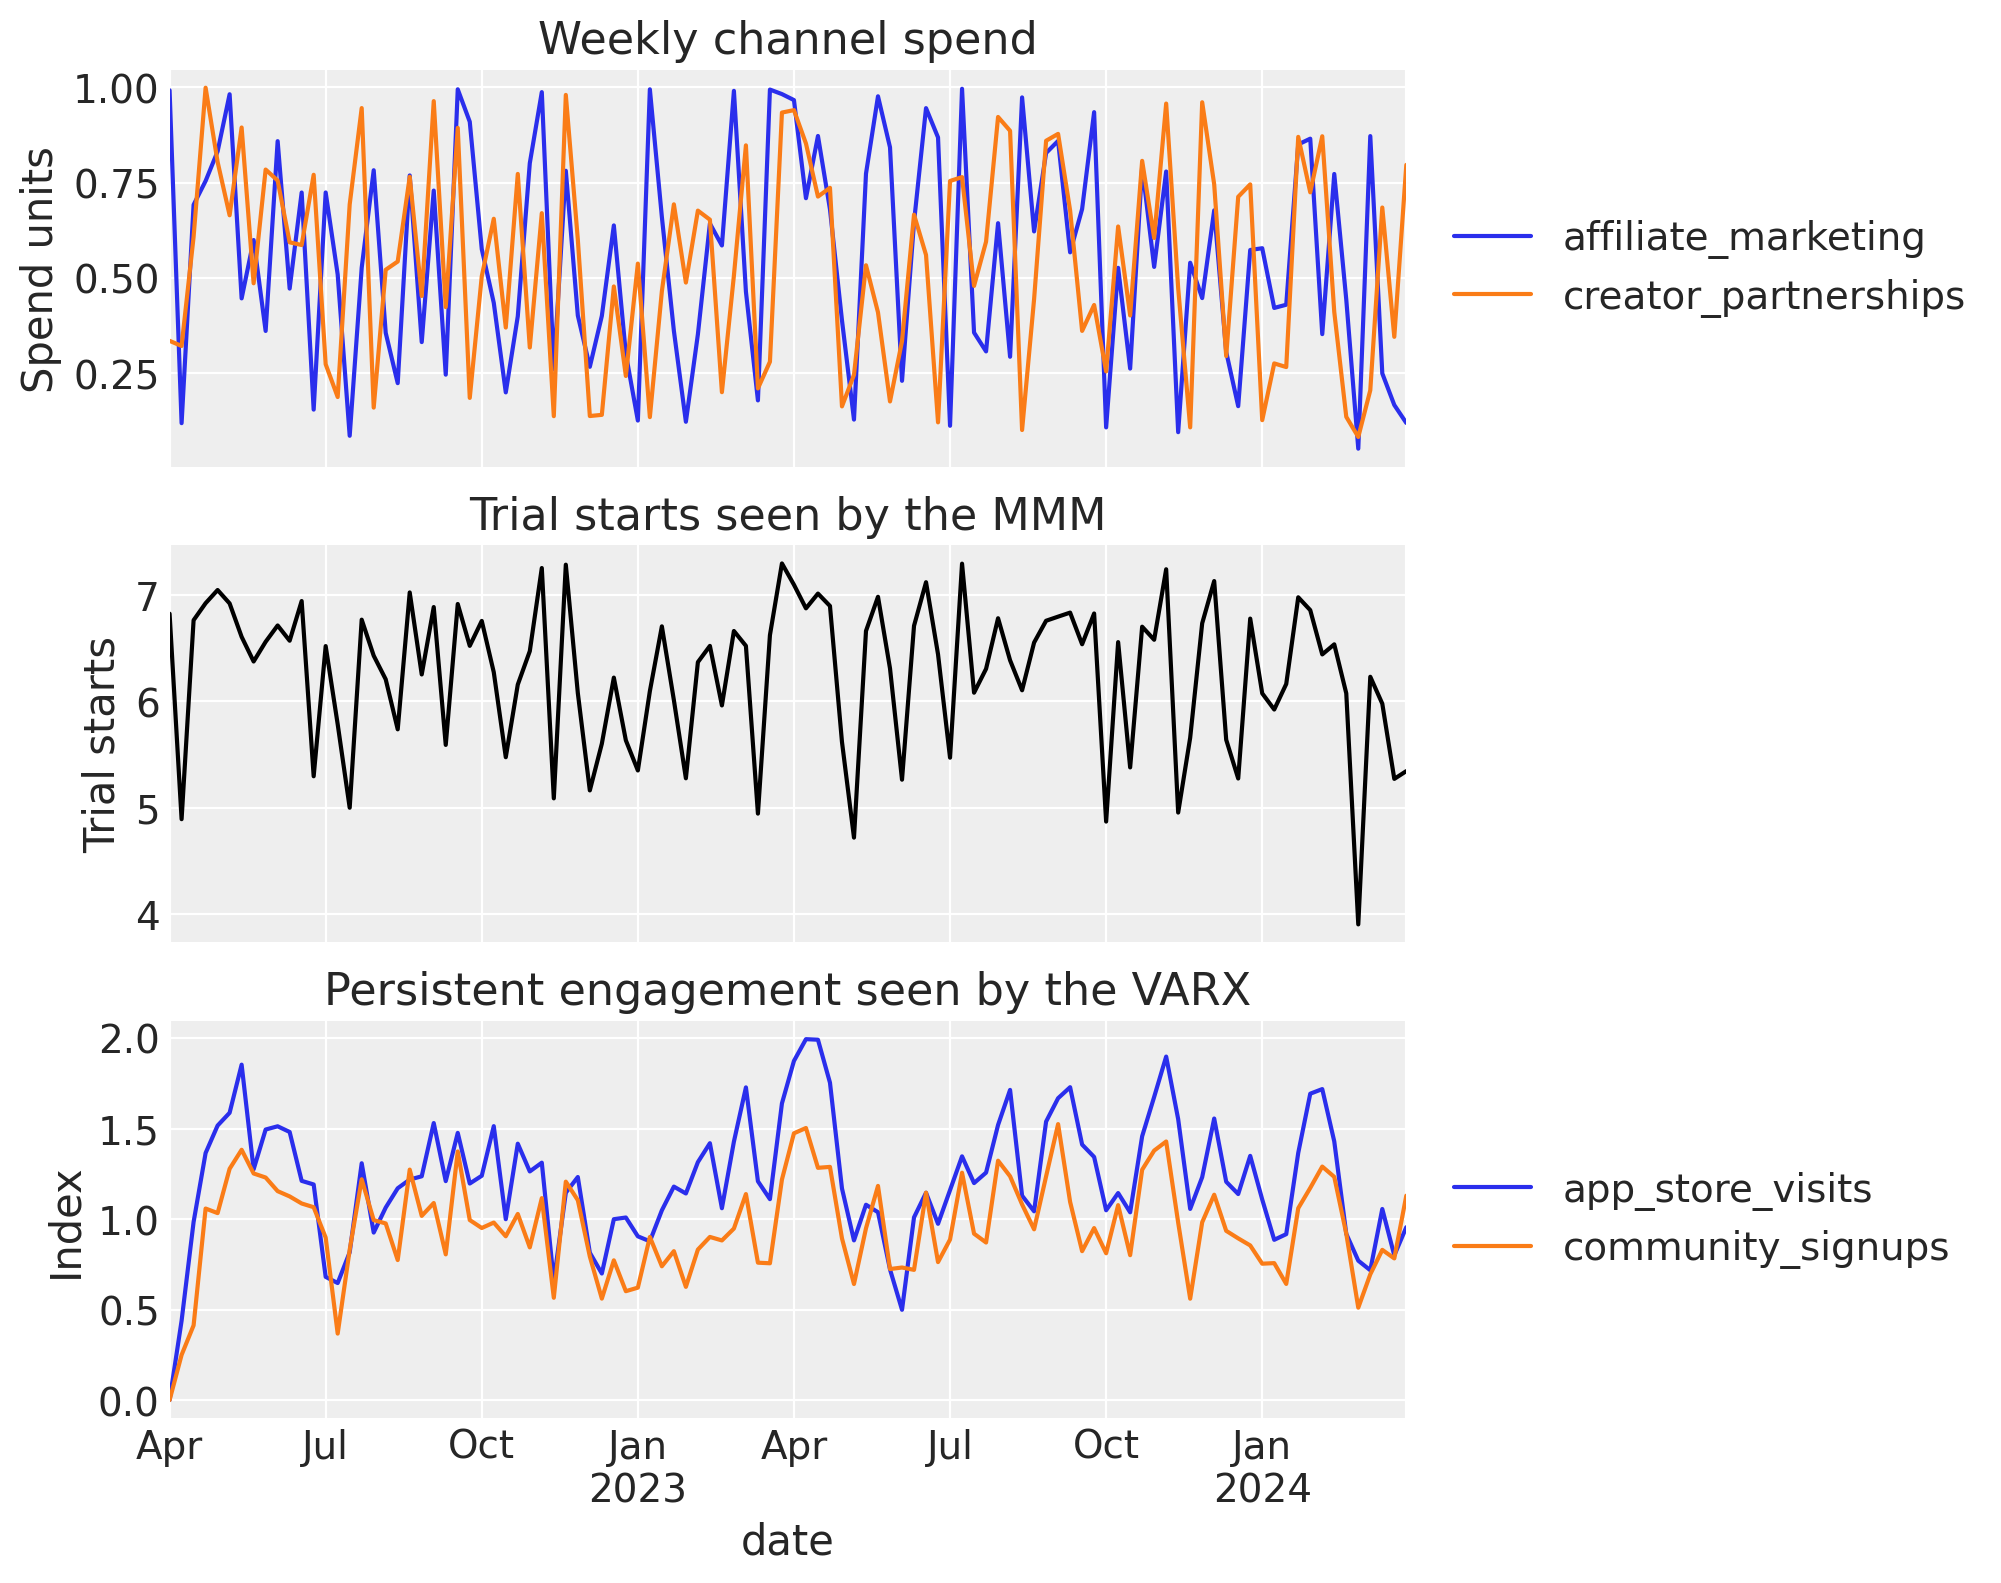

In [19]:
fig, axes = plt.subplots(3, 1, figsize=(10, 8), sharex=True)
data.plot(x="date", y=channels, ax=axes[0])
axes[0].set(title="Weekly channel spend", ylabel="Spend units")
axes[0].legend(
    loc="center left",
    bbox_to_anchor=(1.01, 0.5),
)
data.plot(x="date", y="trial_starts", color="black", ax=axes[1], legend=False)
axes[1].set(title="Trial starts seen by the MMM", ylabel="Trial starts")
data.plot(
    x="date",
    y=["app_store_visits", "community_signups"],
    ax=axes[2],
)
axes[2].set(title="Persistent engagement seen by the VARX", ylabel="Index")
axes[2].legend(
    loc="center left",
    bbox_to_anchor=(1.01, 0.5),
)
fig.tight_layout()

## Fit the MMM and VARX

The MMM estimates the direct trial-start response. The VARX estimates how app-store visits and community sign-ups reinforce one another and respond to channel spend. Separate fits are useful when the outcomes live in different data products or serve different modeling teams.

The sampling settings below keep the documentation runnable. A real analysis still needs prior predictive checks, model diagnostics, validation, and sensitivity analysis.

In [20]:
sampling_config = {
    "draws": 500,
    "tune": 500,
    "chains": 4,
    "cores": 1,
    "target_accept": 0.9,
}

X = data[["date", *channels]]
y = data["trial_starts"]

mmm = MMM(
    date_column="date",
    channel_columns=channels,
    target_column="trial_starts",
    adstock=NoAdstock(l_max=1),
    saturation=LogisticSaturation(),
)
mmm.build_model(X, y)
_ = mmm.fit(
    X=X,
    y=y,
    nuts_sampler="pymc",
    progressbar=False,
    random_seed=seed + 1,
    **sampling_config,
)

Initializing NUTS using jitter+adapt_diag...
Sequential sampling (4 chains in 1 job)
NUTS: [saturation_lam, saturation_beta, y_sigma, intercept_contribution]
Sampling 4 chains for 500 tune and 500 draw iterations (2_000 + 2_000 draws total) took 4 seconds.
The rhat statistic is larger than 1.01 for some parameters. This indicates problems during sampling. See https://arxiv.org/abs/1903.08008 for details


Output()

In [21]:
var_frame = data.set_index("date")[["app_store_visits", "community_signups", *channels]]
var_data = VARData.from_df(
    var_frame,
    endog=["app_store_visits", "community_signups"],
    exog=channels,
)
varx = VAR(lags=1).fit(
    var_data,
    sampler=NUTSSampler(
        nuts_sampler="pymc",
        progressbar=False,
        random_seed=seed + 2,
        **sampling_config,
    ),
)

Initializing NUTS using jitter+adapt_diag...
Sequential sampling (4 chains in 1 job)
NUTS: [intercept, B, B_exog, sigma_sd, tril_offdiag]
Sampling 4 chains for 500 tune and 500 draw iterations (2_000 + 2_000 draws total) took 5 seconds.


In [22]:
diagnostics = pd.DataFrame(
    {
        "divergences": [
            int(mmm.idata.sample_stats["diverging"].sum()),
            int(varx.idata.sample_stats["diverging"].sum()),
        ],
        "maximum r_hat": [
            float(
                az.summary(
                    mmm.idata,
                    var_names=["saturation_lam", "saturation_beta"],
                )["r_hat"].max()
            ),
            float(az.summary(varx.idata, var_names=["B", "B_exog"])["r_hat"].max()),
        ],
    },
    index=["MMM", "VARX"],
)
diagnostics.round(3)

,divergences,maximum r_hat
MMM,0,1.01
VARX,0,1.00


## Translate VARX Dynamics into a Decision Quantity

For a one-lag VARX,

$$
z_t = a + A z_{t-1} + B_{\text{exog}} x_t + \varepsilon_t,
$$

where $z_t$ contains the indicators and $x_t$ contains spend. A one-unit increase in spend today changes the indicators at horizon $h$ by

$$
\Psi_h = A^h B_{\text{exog}}.
$$

This object is a **dynamic multiplier**. It needs no structural-shock identification because the planner sets the exogenous input $x_t$. Impulso's `compute_ma_phi` and `lag_matrices` functions evaluate the multiplier for every posterior draw. We then accumulate the response because the planned weekly budget repeats throughout the horizon.

In [23]:
planning_periods = 8
posterior = varx.idata.posterior
B_draws = posterior["B"].transpose("chain", "draw", "var", "coeff").values
B_exog_draws = posterior["B_exog"].transpose("chain", "draw", "var", "exog").values

phi = compute_ma_phi(
    lag_matrices(B_draws, n_lags=varx.n_lags),
    horizon=planning_periods - 1,
)
impulse_multiplier = phi @ B_exog_draws[:, :, np.newaxis, :, :]
cumulative_draws = np.cumsum(impulse_multiplier, axis=2)

cumulative_multiplier = xr.DataArray(
    cumulative_draws,
    dims=("chain", "draw", "horizon", "response", "channel"),
    coords={
        "horizon": np.arange(planning_periods),
        "response": varx.var_names,
        "channel": channels,
    },
    name="cumulative_dynamic_multiplier",
)
cumulative_multiplier

<xarray.DataArray 'cumulative_dynamic_multiplier' (chain: 4, draw: 500,
                                                   horizon: 8, response: 2,
                                                   channel: 2)> Size: 512kB
array([[[[[ 0.18181121,  0.75208021],
          [ 0.32164542,  0.66471982]],

         [[ 0.29172074,  1.21652114],
          [ 0.47856771,  1.00096232]],

         [[ 0.35871553,  1.5044245 ],
          [ 0.555799  ,  1.17371353]],

         ...,

         [[ 0.44087981,  1.86457124],
          [ 0.62348038,  1.33831098]],

         [[ 0.45063517,  1.90808393],
          [ 0.62863212,  1.35281139]],

         [[ 0.45671055,  1.93530708],
          [ 0.63136269,  1.36100651]]],

...

        [[[ 0.23871748,  0.7532798 ],
          [ 0.18449785,  0.6540587 ]],

         [[ 0.36718496,  1.15305312],
          [ 0.28926979,  1.02285385]],

         [[ 0.43589268,  1.36352484],
          [ 0.3485667 ,  1.2300954 ]],

         ...,

         [[ 0.50165477,  1.55880777],
          [ 0.41134809,  1.44692723]],

         [[ 0.50684191,  1.57326182],
          [ 0.41722807,  1.46687502]],

         [[ 0.50948737,  1.58035535],
          [ 0.42049872,  1.47788183]]]]], shape=(4, 500, 8, 2, 2))
Coordinates:
  * horizon   (horizon) int64 64B 0 1 2 3 4 5 6 7
  * response  (response) <U17 136B 'app_store_visits' 'community_signups'
  * channel   (channel) <U20 160B 'affiliate_marketing' 'creator_partnerships'
Dimensions without coordinates: chain, draw

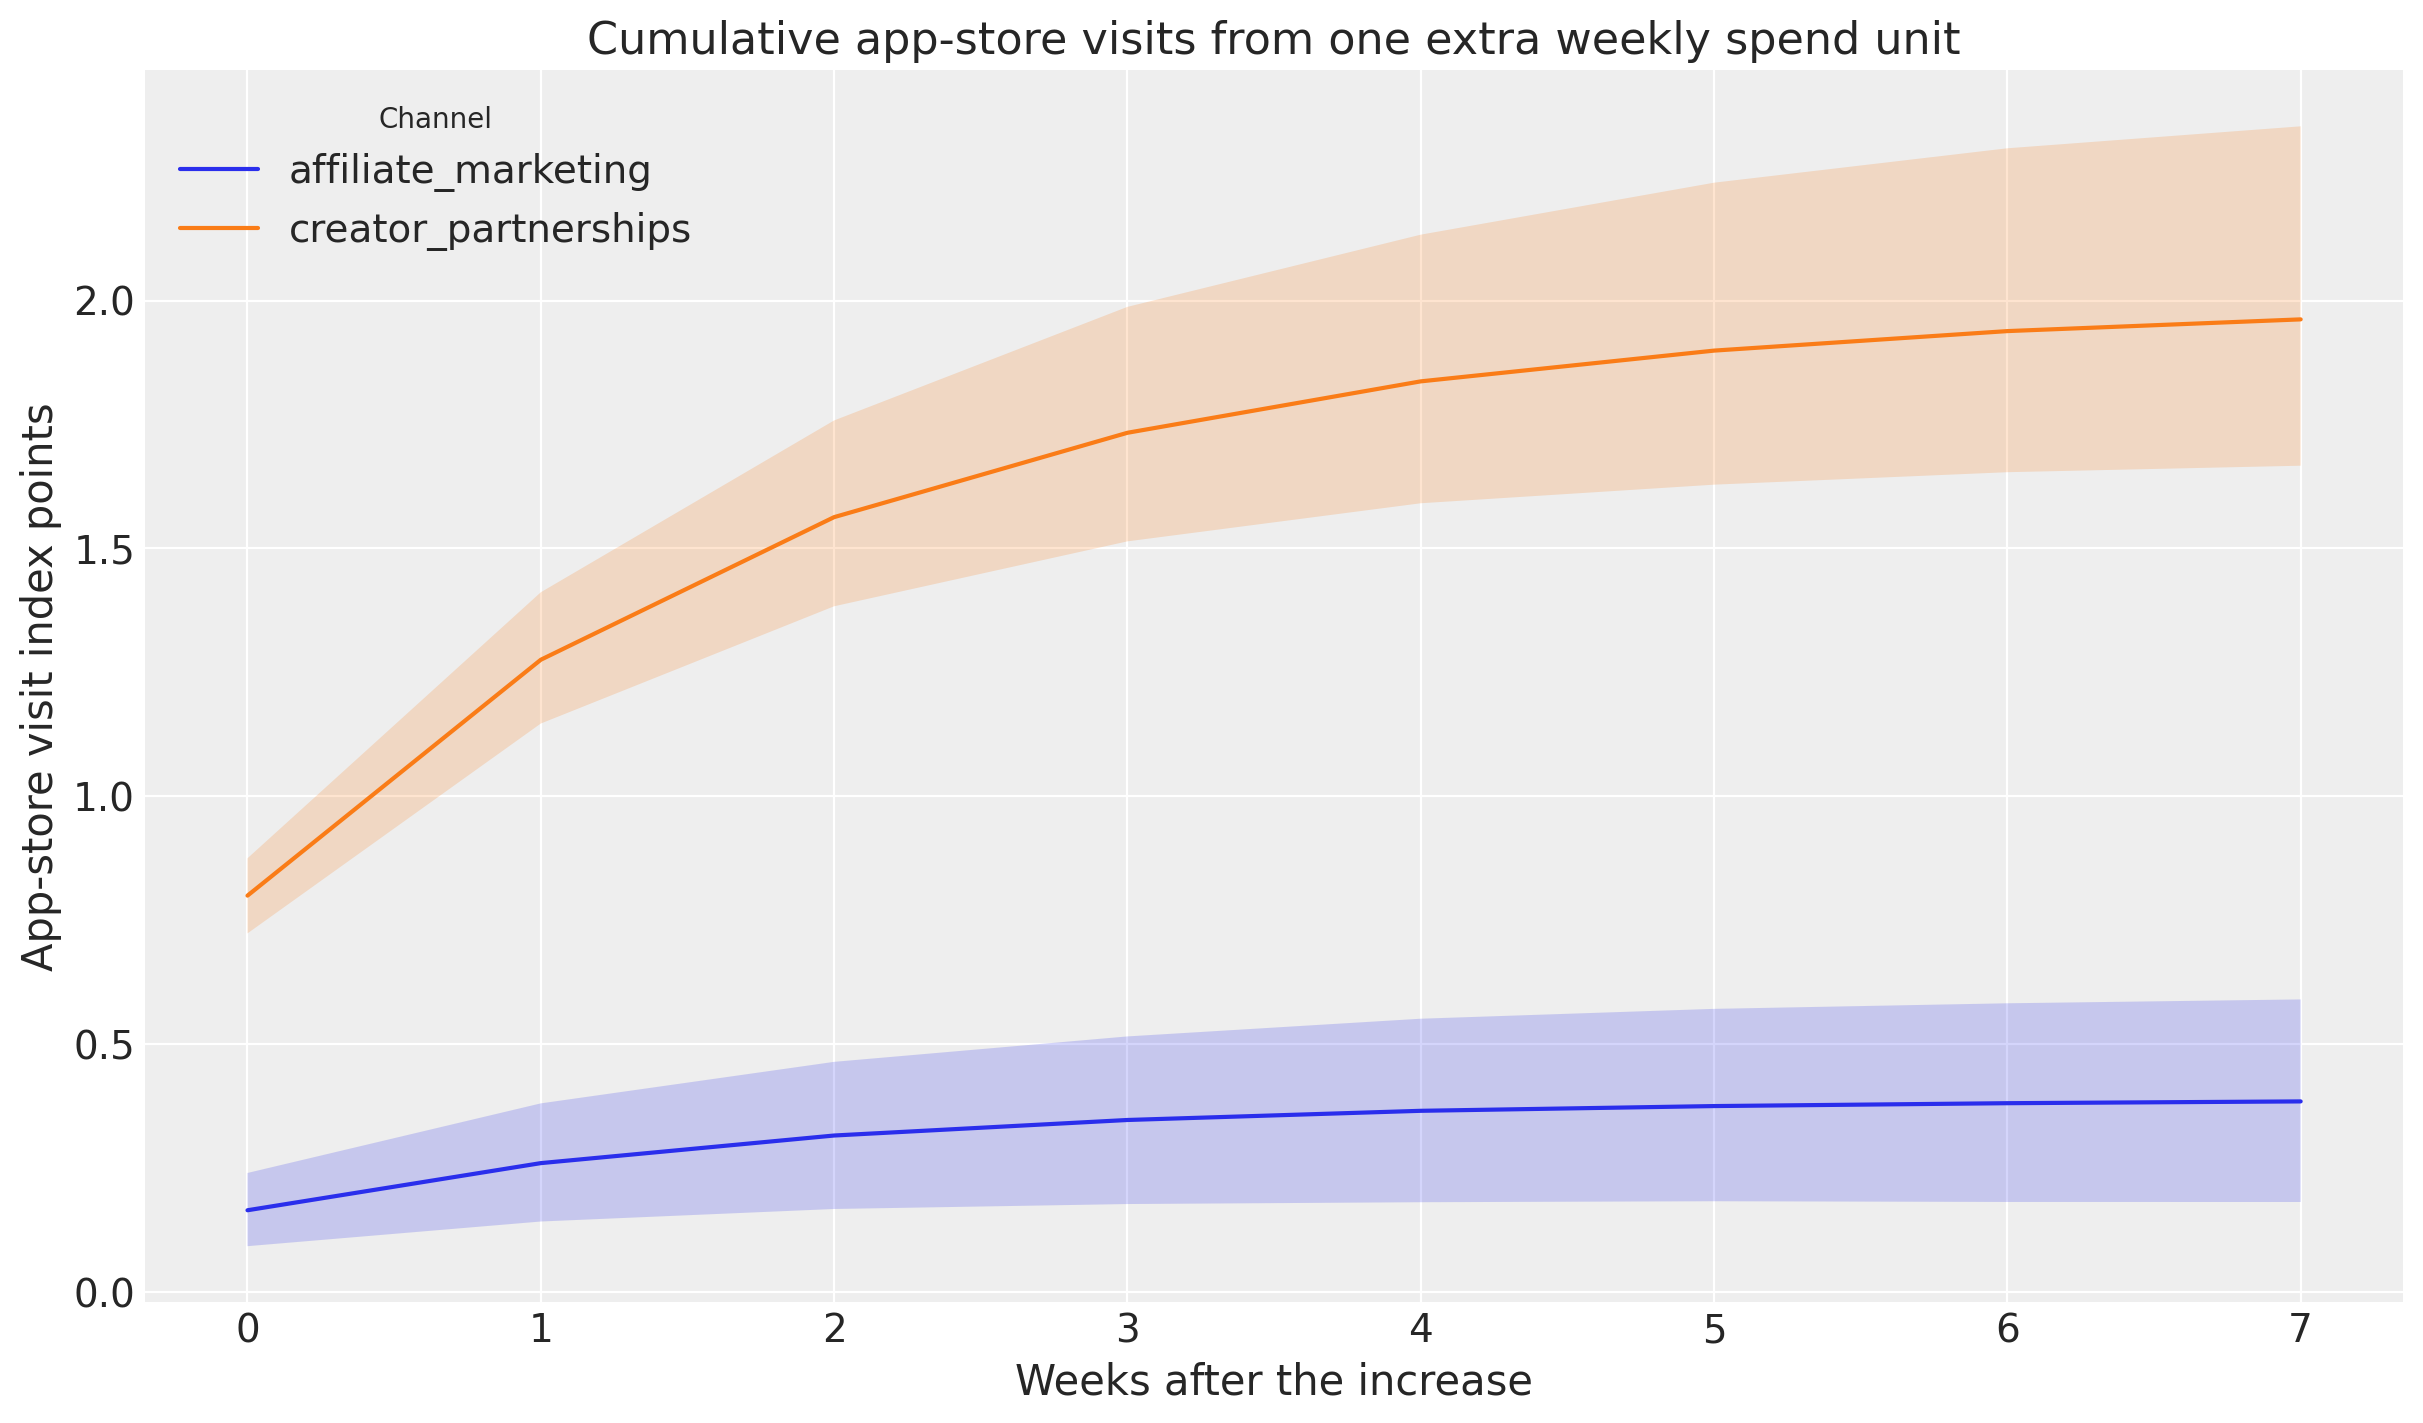

In [24]:
app_store_multiplier = cumulative_multiplier.sel(response="app_store_visits")
app_store_quantiles = app_store_multiplier.quantile(
    [0.05, 0.5, 0.95], dim=("chain", "draw")
)

fig, ax = plt.subplots()
for channel in channels:
    median = app_store_quantiles.sel(quantile=0.5, channel=channel)
    lower = app_store_quantiles.sel(quantile=0.05, channel=channel)
    upper = app_store_quantiles.sel(quantile=0.95, channel=channel)
    ax.plot(median["horizon"], median, label=channel)
    ax.fill_between(median["horizon"], lower, upper, alpha=0.2)
ax.set(
    title="Cumulative app-store visits from one extra weekly spend unit",
    xlabel="Weeks after the increase",
    ylabel="App-store visit index points",
)
ax.legend(title="Channel")

The VARX gives creator partnerships the larger app-store-visit multiplier. The gap grows with the horizon because visits lead to community sign-ups, while community activity creates referrals that feed visits back.

For a constant weekly allocation $x$ over $H$ weeks, total incremental app-store visits are

$$
\sum_{t=0}^{H-1} \left(\sum_{h=0}^{t} \Psi_h\right)x = c^\top x.
$$

The vector $c$ is the area under the cumulative multiplier curve. We calculate one $c$ for every VARX posterior draw, then pair those draws with the MMM's posterior draws. Because the models were fitted separately, this pairing represents an independence assumption rather than estimated cross-model dependence.

In [25]:
app_store_coefficients = app_store_multiplier.sum("horizon")
app_store_coefficient_draws = (
    app_store_coefficients.stack(sample=("chain", "draw"))
    .transpose("sample", "channel")
    .values
)

n_mmm_samples = mmm.idata.posterior.sizes["chain"] * mmm.idata.posterior.sizes["draw"]
if app_store_coefficient_draws.shape[0] != n_mmm_samples:
    raise ValueError(
        "The MMM and VARX must provide the same number of posterior samples."
    )

coefficient_summary = pd.DataFrame(
    {
        "posterior mean": app_store_coefficients.mean(("chain", "draw")).values,
        "posterior sd": app_store_coefficients.std(("chain", "draw")).values,
    },
    index=pd.Index(channels, name="channel"),
)
coefficient_summary.round(2)

,posterior mean,posterior sd
channel,,
affiliate_marketing,2.58,0.78
creator_partnerships,13.06,1.11


## Optimize Across Both Models

The optimizer now evaluates each posterior sample with

$$
U_w^{(s)}(x) = R_{\text{MMM}}^{(s)}(x) + w\,c^{(s)\top}x,
$$

then maximizes the posterior mean subject to the total budget and channel bounds. $R_{\text{MMM}}$ is the direct trial-start contribution, $c^\top x$ is total app-store activity over the planning window, and $w$ converts app-store visit index points into trial-start-response units.

The custom utility below uses PyMC-Marketing's public utility-function extension point. It adds the VARX term **draw by draw**, so the objective retains uncertainty from both models.

In [26]:
def make_joint_utility(
    coefficient_draws: np.ndarray, weight: float
) -> UtilityFunctionType:
    """Create a posterior-mean utility with an added VARX response term."""
    coefficient_tensor = as_xtensor(
        pt.constant(coefficient_draws), dims=("sample", "channel")
    )

    def joint_utility(
        samples: XTensorVariable, budgets: XTensorVariable
    ) -> XTensorVariable:
        app_store_response = (coefficient_tensor * budgets).sum(dim="channel")
        return (samples + weight * app_store_response).mean(dim="sample")

    return joint_utility

In [27]:
start_date = dates[-1] + pd.Timedelta(weeks=1)
end_date = start_date + pd.Timedelta(weeks=planning_periods - 1)
mmm_wrapper = BudgetOptimizerWrapper(
    model=mmm,
    start_date=str(start_date.date()),
    end_date=str(end_date.date()),
)
if mmm_wrapper.num_periods != planning_periods:
    raise ValueError("The optimizer horizon does not match the VARX horizon.")

weekly_budget = 1.2
budget_bounds = {channel: (0.05, 1.15) for channel in channels}

baseline_optimizer = BudgetOptimizer(
    model=mmm_wrapper,
    num_periods=planning_periods,
)
baseline_allocation, baseline_result = baseline_optimizer.allocate_budget(
    total_budget=weekly_budget,
    budget_bounds=budget_bounds,
)
if not baseline_result.success:
    raise RuntimeError(baseline_result.message)

baseline_allocation.to_series().round(3)

channel
affiliate_marketing     0.677
creator_partnerships    0.523
dtype: float64

In [28]:
weight_grid = [0.0, 0.2, 0.5, 1.0]
allocations = {}
for weight in weight_grid:
    optimizer = BudgetOptimizer(
        model=mmm_wrapper,
        num_periods=planning_periods,
        utility_function=make_joint_utility(app_store_coefficient_draws, weight),
    )
    allocation, result = optimizer.allocate_budget(
        total_budget=weekly_budget,
        budget_bounds=budget_bounds,
    )
    if not result.success:
        raise RuntimeError(result.message)
    allocations[weight] = allocation.to_series()

allocation_by_weight = pd.DataFrame(allocations).T
allocation_by_weight.index.name = "app-store-visit weight"
np.testing.assert_allclose(
    allocation_by_weight.loc[0.0],
    baseline_allocation.to_series(),
    atol=1e-3,
)
allocation_by_weight.round(3)

channel,affiliate_marketing,creator_partnerships
app-store-visit weight,,
0.0,0.677,0.523
0.2,0.638,0.562
0.5,0.584,0.616
1.0,0.502,0.698


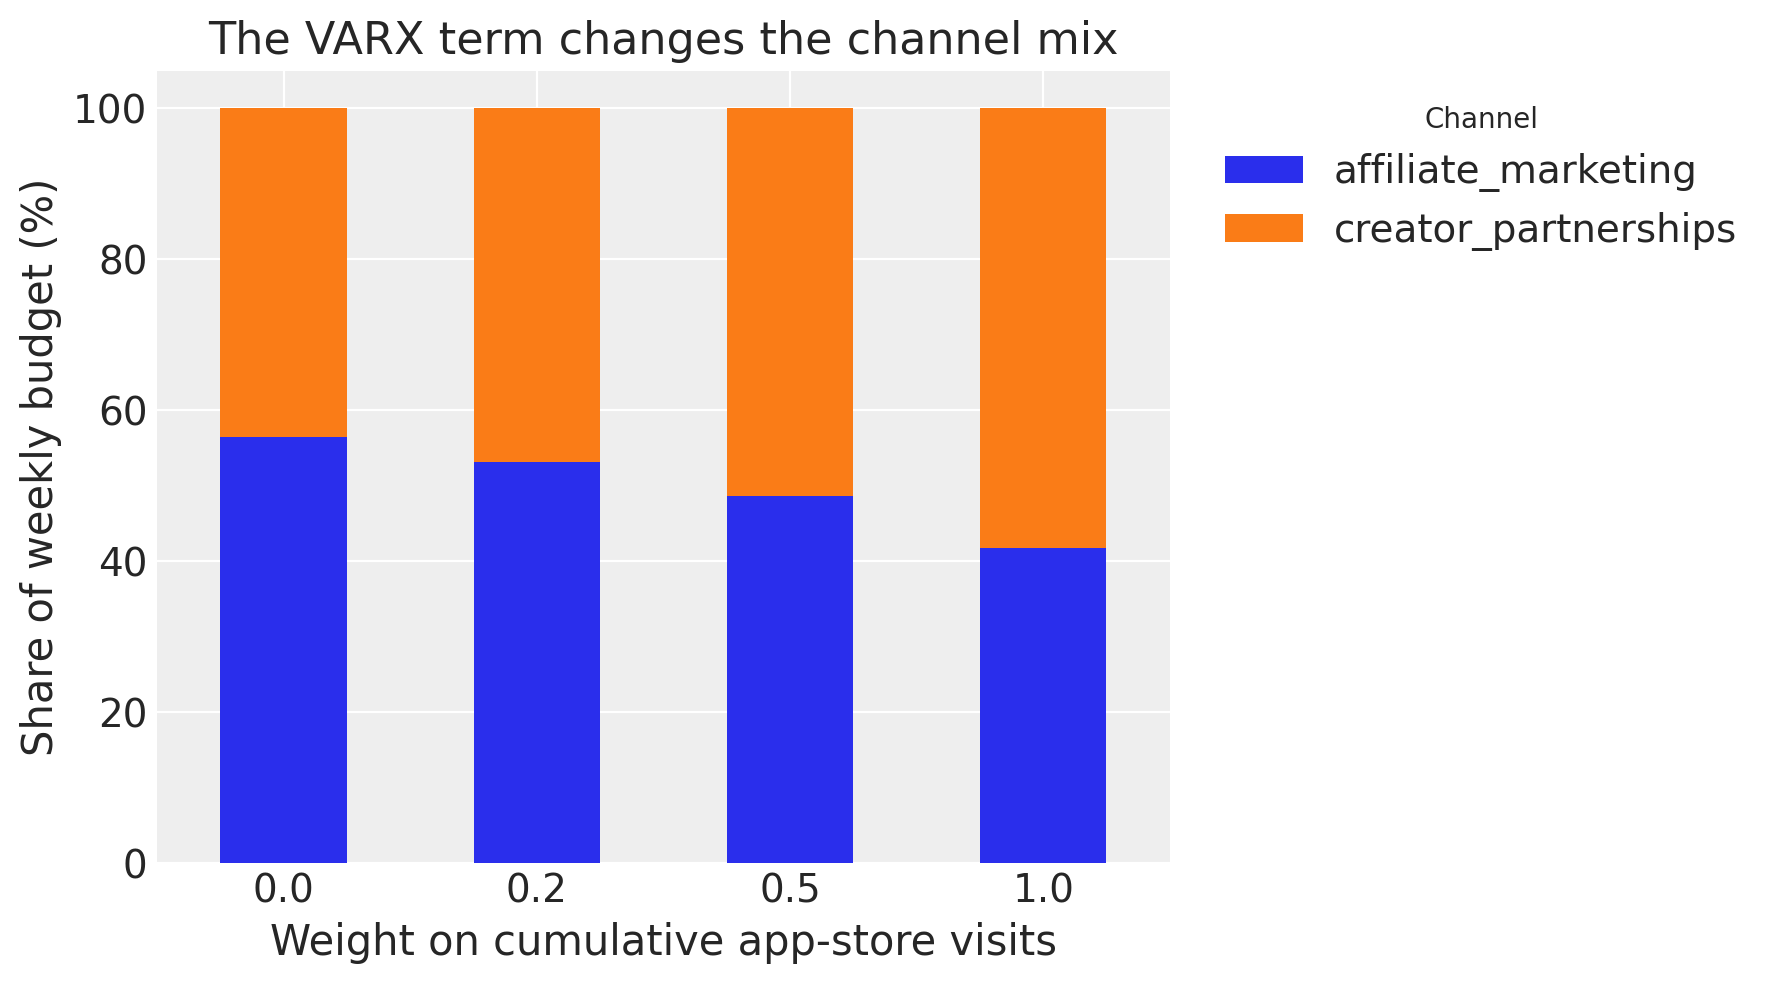

In [29]:
share_by_weight = allocation_by_weight.div(weekly_budget).mul(100)
ax = share_by_weight.plot(
    kind="bar",
    stacked=True,
    color=["C0", "C1"],
    figsize=(9, 5),
)
ax.set(
    title="The VARX term changes the channel mix",
    xlabel="Weight on cumulative app-store visits",
    ylabel="Share of weekly budget (%)",
)
ax.tick_params(axis="x", rotation=0)
ax.legend(title="Channel", bbox_to_anchor=(1.02, 1), loc="upper left")
plt.tight_layout()

At weight zero, the custom utility reproduces the MMM-only allocation. As the planner values app-store visits more highly, the optimizer moves budget toward creator partnerships while preserving the weekly budget total. The exercise does not reveal a universal best weight; it exposes the trade-off so decision-makers can inspect it.

## Key Takeaways

1. **One decision can use two fitted models.** Separately fitted Bayesian models can inform a single PyMC-Marketing budget allocation.
2. **Dynamic multipliers connect models to decisions.** The VARX trajectory becomes the linear term needed to value a repeated weekly allocation.
3. **Draw-wise composition preserves uncertainty.** Combining responses for each posterior draw supports later extensions to risk-sensitive utilities or probabilistic constraints.

## Practical Considerations

- **Posterior propagation is not joint estimation.** Independent fits cannot learn cross-model parameter or shock correlation.
- **Exogeneity is an assumption.** The multiplier supports an intervention only when the planner sets spend independently of unmodeled indicator shocks.
- **The weight is a business exchange rate.** Inspect a range of values rather than reporting one allocation without sensitivity analysis.
- **Avoid double counting.** Keep the VARX response distinct from effects already represented in the MMM target and transformations.
- **Linear VARX effects do not saturate.** Realistic budget bounds become important when the persistent term receives a large weight.
- **This plan repeats one weekly allocation.** A pacing problem needs a time-varying decision vector and the full multiplier matrix.

In [30]:
%load_ext watermark
%watermark -n -u -v -iv -w -p pymc_marketing,impulso

The watermark extension is already loaded. To reload it, use:
  %reload_ext watermark
Last updated: Thu, 30 Jul 2026

Python implementation: CPython
Python version       : 3.13.12
IPython version      : 9.15.0

pymc_marketing: 1.0.0.dev0
impulso       : 0.0.8

arviz         : 1.2.0
impulso       : 0.0.8
matplotlib    : 3.10.9
numpy         : 2.4.6
pandas        : 3.0.5
pymc_marketing: 1.0.0.dev0
pytensor      : 3.0.7
xarray        : 2026.4.0

Watermark: 2.6.0

